In [2]:
import numpy as np

print("Loading Master DataCube and extracting Test Slice...")

# =====================================================================
# 0. LOAD DATA & EXTRACT TEST SLICE
# =====================================================================
# Load the master datacube in read-only mode to save RAM
master_data = np.load("Delhi_NCR_Master_DataCube_Scaled.npy", mmap_mode='r')

# Extract an 8-day block from the test partition (Index 2557 starts in the test set)
# test_slice[0:7] will be the 7-day historical input
# test_slice[7] will be the 'Day 8' Ground Truth Reality
test_slice = master_data[2557 : 2557 + 8]

print(f"Test slice extracted successfully! Shape: {test_slice.shape}")

Loading Master DataCube and extracting Test Slice...
Test slice extracted successfully! Shape: (8, 141, 231, 6)


### Conv-GRU 

Generating Conv-GRU Prediction vs. Reality Analysis...


/home/yashaswi-garg/anaconda3/envs/aerosense/lib/python3.10/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'spatiotemporal_conv_gru', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 821ms/step
Visualizations saved successfully to disk.


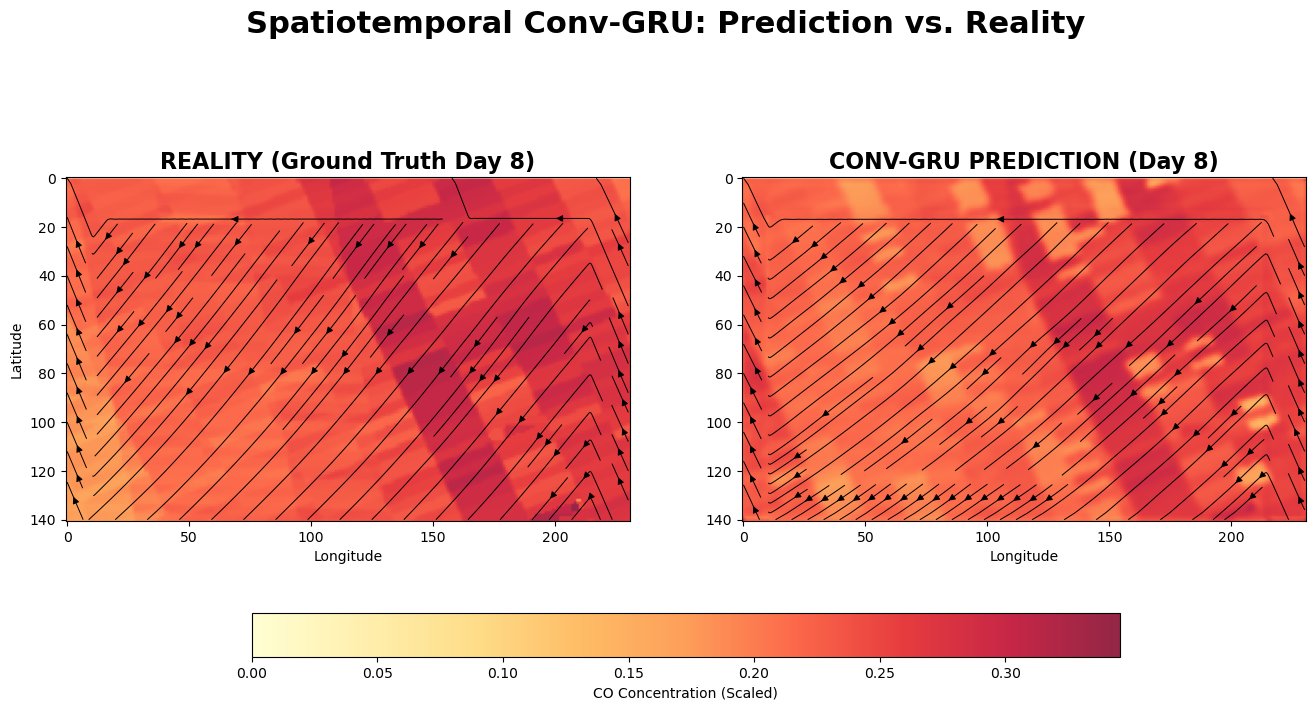

In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("Generating Conv-GRU Prediction vs. Reality Analysis...")

# =====================================================================
# 1. THE CUSTOM LAYER (REQUIRED TO LOAD CONV-GRU)
# =====================================================================
class SpatiotemporalConvGRU(tf.keras.layers.Layer):
    def __init__(self, filters=32, **kwargs):
        super(SpatiotemporalConvGRU, self).__init__(**kwargs)
        self.filters = filters
        self.conv_z = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='sigmoid', name='Update_Gate')
        self.conv_r = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='sigmoid', name='Reset_Gate')
        self.conv_h = tf.keras.layers.Conv2D(filters, 3, padding='same', activation='tanh', name='Candidate_H')

    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        h = tf.zeros((batch_size, 141, 231, self.filters))
        for t in range(7):
            x_t = inputs[:, t, :, :, :] 
            concat_xh = tf.concat([x_t, h], axis=-1)
            z = self.conv_z(concat_xh)
            r = self.conv_r(concat_xh)
            concat_x_rh = tf.concat([x_t, r * h], axis=-1)
            h_tilde = self.conv_h(concat_x_rh)
            h = (1.0 - z) * h + z * h_tilde
        return h

    def get_config(self):
        config = super(SpatiotemporalConvGRU, self).get_config()
        config.update({"filters": self.filters})
        return config

# =====================================================================
# 2. LOAD MODEL & PREPARE DATA
# =====================================================================
# Load using custom_objects
model = tf.keras.models.load_model(
    "Delhi_NCR_ConvGRU_Baseline.keras", 
    compile=False,
    custom_objects={"SpatiotemporalConvGRU": SpatiotemporalConvGRU}
)

# Get the 7-day input and the REAL Day 8
X_input = np.expand_dims(test_slice[0:7], axis=0).astype('float16')
X_input = np.nan_to_num(X_input, nan=0.0, posinf=1.0, neginf=0.0)

actual_day8 = test_slice[7] # The reality

# Get the AI's Prediction for Day 8
predicted_day8 = model.predict(X_input)[0]

# Extract CO channels (Channel Index 2)
real_co = actual_day8[:, :, 2]
pred_co = predicted_day8[:, :, 2]

# Extract Wind (Using indices 3 and 4 for U and V wind based on your datacube)
real_u = actual_day8[:, :, 3] - 0.5
real_v = actual_day8[:, :, 4] - 0.5
pred_u = predicted_day8[:, :, 3] - 0.5
pred_v = predicted_day8[:, :, 4] - 0.5

# Prepare Grid for Quiver/Streamplot
x = np.arange(231)
y = np.arange(141)
X, Y = np.meshgrid(x, y)

# =====================================================================
# 3. RENDER THE 2-PANEL COMPARISON
# =====================================================================
# Adjusted figsize for 2 panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1: REALITY
im1 = ax1.imshow(real_co, cmap='YlOrRd', origin='upper', alpha=0.85, vmin=0.0, vmax=np.max(real_co))
ax1.streamplot(X, Y, real_u, real_v, color='black', linewidth=0.7, density=1.2)
ax1.set_title("REALITY (Ground Truth Day 8)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# Panel 2: PREDICTION
im2 = ax2.imshow(pred_co, cmap='YlOrRd', origin='upper', alpha=0.85, vmin=0.0, vmax=np.max(real_co))
ax2.streamplot(X, Y, pred_u, pred_v, color='black', linewidth=0.7, density=1.2)
ax2.set_title("CONV-GRU PREDICTION (Day 8)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Longitude")

# Add main colorbar for Reality/Prediction
fig.colorbar(im1, ax=[ax1, ax2], shrink=0.7, location='bottom', label='CO Concentration (Scaled)')

plt.suptitle("Spatiotemporal Conv-GRU: Prediction vs. Reality", fontsize=22, fontweight='bold', y=0.98)
plt.savefig("ConvGRU_Prediction_Vs_Reality.png", dpi=300, bbox_inches='tight')

print("Visualizations saved successfully to disk.")
plt.show()

### Conv-LSTM

Generating Prediction vs. Reality Analysis...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Visualizations saved successfully to disk.


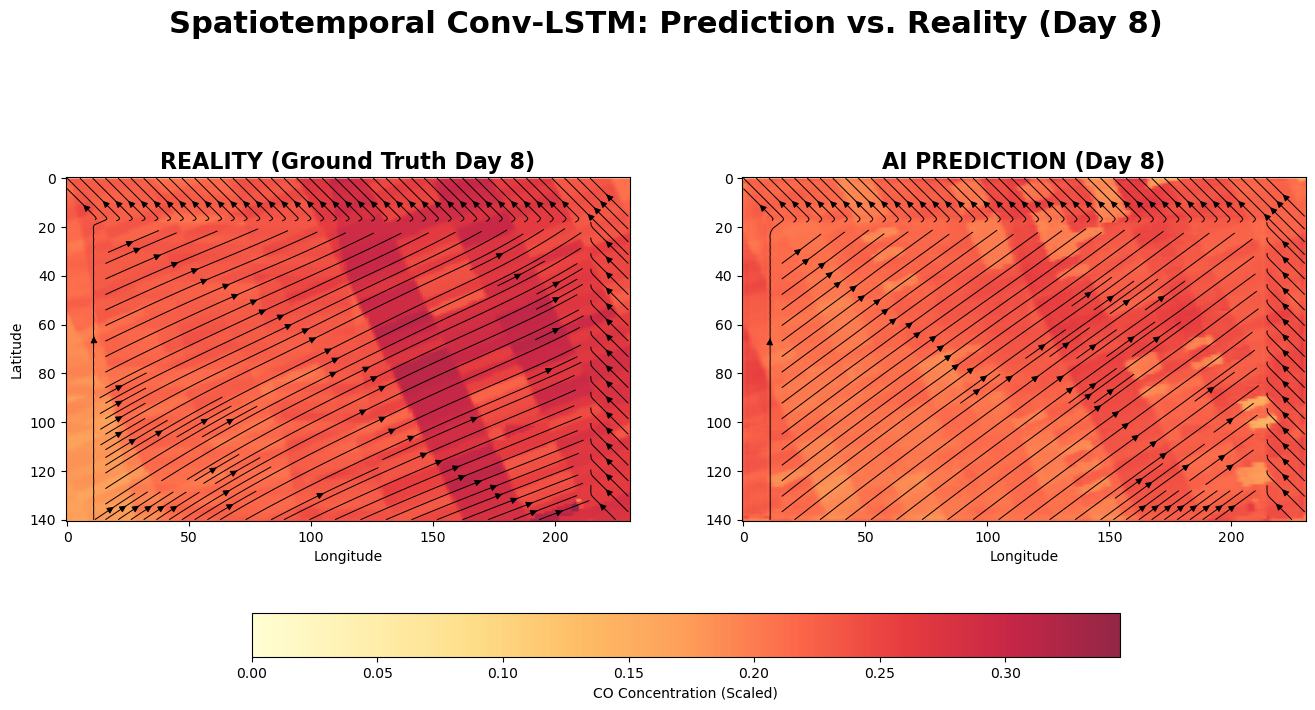

In [8]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("Generating Prediction vs. Reality Analysis...")

# 1. LOAD MODEL & PREPARE DATA
model = tf.keras.models.load_model("Delhi_NCR_Air_Quality_Best_Model.keras", compile=False)

# Get the 7-day input and the REAL Day 8
X_input = np.expand_dims(test_slice[0:7], axis=0)
X_input = np.nan_to_num(X_input, nan=0.0, posinf=1.0, neginf=0.0)

actual_day8 = test_slice[7] # The reality

# Get the AI's Prediction for Day 8
predicted_day8 = model.predict(X_input)[0]

# Extract CO channels
real_co = actual_day8[:, :, 2]
pred_co = predicted_day8[:, :, 2]

# Extract Wind (Actual vs Predicted)
real_u = actual_day8[:, :, 4] - 0.5
real_v = actual_day8[:, :, 5] - 0.5
pred_u = predicted_day8[:, :, 4] - 0.5
pred_v = predicted_day8[:, :, 5] - 0.5

# Prepare Grid
x = np.arange(231)
y = np.arange(141)
X, Y = np.meshgrid(x, y)

# 2. RENDER THE 2-PANEL COMPARISON
# Adjusted figsize for 2 panels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Panel 1: REALITY
im1 = ax1.imshow(real_co, cmap='YlOrRd', origin='upper', alpha=0.85, vmin=0.0, vmax=np.max(real_co))
ax1.streamplot(X, Y, real_u, real_v, color='black', linewidth=0.7, density=1.5)
ax1.set_title("REALITY (Ground Truth Day 8)", fontsize=16, fontweight='bold')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")

# Panel 2: PREDICTION
im2 = ax2.imshow(pred_co, cmap='YlOrRd', origin='upper', alpha=0.85, vmin=0.0, vmax=np.max(real_co))
ax2.streamplot(X, Y, pred_u, pred_v, color='black', linewidth=0.7, density=1.5)
ax2.set_title("AI PREDICTION (Day 8)", fontsize=16, fontweight='bold')
ax2.set_xlabel("Longitude")

# Add main colorbar for Reality/Prediction
fig.colorbar(im1, ax=[ax1, ax2], shrink=0.7, location='bottom', label='CO Concentration (Scaled)')

plt.suptitle("Spatiotemporal Conv-LSTM: Prediction vs. Reality (Day 8)", fontsize=22, fontweight='bold', y=0.98)
plt.savefig("Baseline_Prediction_Vs_Reality.png", dpi=300, bbox_inches='tight')

print("Visualizations saved successfully to disk.")
plt.show()